In [1]:
import yaml
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
from itertools import product
from datetime import datetime
from pathlib import Path
import json

from thesis_project.models.keyword_spotting import KWSBase, KWSDynamic
from thesis_project.models.components.routers import GRURouter
from thesis_project.utils.paths import get_data_dir
from thesis_project.datasets import SpeechCommandsGoogle
from base_config_temp import cfg, noise_train_cfg, noise_eval_cfg
from thesis_project.training.key_word_spotting import CrossEntropyPlusRankLoss, fit_dynamic_model, validate_dynamic_model
from thesis_project.models.components.layers import LowRankPointwiseConv1d

In [2]:
import re

def parse_run_folder_name(folder_name):
    """
    Parse folder name to extract hyperparameters.
    Expected format: YYYY-MM-DD_HH-MM-SS_rank_XX_weight_YY_mode_ZZ
    """
    # Try to extract from folder name
    rank_match = re.search(r'rank_(\d+)', folder_name)
    weight_match = re.search(r'weight_([\d.]+)', folder_name)
    mode_match = re.search(r'mode_(\w+)', folder_name)
    
    target_rank = int(rank_match.group(1)) if rank_match else None
    rank_loss_weight = float(weight_match.group(1)) if weight_match else None
    rank_loss_mode = mode_match.group(1) if mode_match else None
    
    return target_rank, rank_loss_weight, rank_loss_mode


def extract_metrics_from_history(history_path):
    """
    Load history.npy and extract the metrics we need.
    """
    try:
        history = np.load(history_path, allow_pickle=True).item()
        epochs_log = history.get("epochs_log", [])
        
        if not epochs_log:
            return None
        
        last_epoch = epochs_log[-1]
        val_accs = [e.get("val_acc") for e in epochs_log if e.get("val_acc") is not None]
        val_losses = [e.get("val_loss") for e in epochs_log if e.get("val_loss") is not None]
        
        # Find epochs with best metrics
        best_val_acc_idx = val_accs.index(max(val_accs)) if val_accs else None
        best_val_loss_idx = val_losses.index(min(val_losses)) if val_losses else None
        
        metrics = {
            "final_train_loss": last_epoch.get("train_loss"),
            "final_train_acc": last_epoch.get("train_acc"),
            "best_val_acc": max(val_accs) if val_accs else None,
            "best_val_acc_loss": epochs_log[best_val_acc_idx].get("val_loss") if best_val_acc_idx is not None else None,
            "best_val_acc_rank": epochs_log[best_val_acc_idx].get("train_expected_rank") if best_val_acc_idx is not None else None,
            "best_val_loss": min(val_losses) if val_losses else None,
            "best_val_loss_acc": epochs_log[best_val_loss_idx].get("val_acc") if best_val_loss_idx is not None else None,
            "best_val_loss_rank": epochs_log[best_val_loss_idx].get("train_expected_rank") if best_val_loss_idx is not None else None,
            "final_epoch_rank": last_epoch.get("train_expected_rank"),
        }
        
        return metrics
    
    except Exception as e:
        print(f"Error loading {history_path}: {e}")
        return None


def recreate_sweep_results(sweep_folder):
    """
    Scan sweep folder, load all history files, and create sweep_results_updated.json
    """
    sweep_path = Path(sweep_folder)
    
    if not sweep_path.exists():
        print(f"Error: Sweep folder {sweep_folder} does not exist")
        return
    
    sweep_results = []
    
    # Find all subdirectories that contain history.npy
    for run_dir in sorted(sweep_path.iterdir()):
        if not run_dir.is_dir():
            continue
        
        history_path = run_dir / "history.npy"
        
        if not history_path.exists():
            print(f"Warning: No history.npy found in {run_dir.name}, skipping...")
            continue
        
        print(f"Processing {run_dir.name}...")
        
        # Parse hyperparameters from folder name
        target_rank, rank_loss_weight, rank_loss_mode = parse_run_folder_name(run_dir.name)
        
        # Extract metrics from history
        metrics = extract_metrics_from_history(history_path)
        
        if metrics is None:
            print(f"  ✗ Failed to extract metrics")
            sweep_results.append({
                "target_rank": target_rank,
                "rank_loss_weight": rank_loss_weight,
                "rank_loss_mode": rank_loss_mode,
                "error": "Failed to extract metrics",
                "run_dir": str(run_dir),
            })
            continue
        
        # Combine hyperparameters and metrics
        result = {
            "target_rank": target_rank,
            "rank_loss_weight": rank_loss_weight,
            "rank_loss_mode": rank_loss_mode,
            **metrics,
            "run_dir": str(run_dir),
        }
        
        sweep_results.append(result)
        print(f"  ✓ Extracted metrics")
        if metrics["best_val_acc"]:
            print(f"    Best val acc: {metrics['best_val_acc']:.2f}%")
        if metrics["best_val_loss"]:
            print(f"    Best val loss: {metrics['best_val_loss']:.4f}")
    
    # Save results
    output_path = sweep_path / "sweep_results_updated.json"
    with open(output_path, "w") as f:
        json.dump(sweep_results, f, indent=2)
    
    print(f"\n{'='*80}")
    print(f"Processed {len(sweep_results)} runs")
    print(f"Results saved to: {output_path}")
    print(f"{'='*80}")
    
    # Print summary of top configurations
    successful_runs = [r for r in sweep_results if "error" not in r and r.get("best_val_acc") is not None]
    if successful_runs:
        successful_runs.sort(key=lambda x: x["best_val_acc"], reverse=True)
        
        print("\nTop 5 configurations:")
        for i, result in enumerate(successful_runs[:5], 1):
            print(f"\n{i}. Rank={result['target_rank']}, Weight={result['rank_loss_weight']}, Mode={result['rank_loss_mode']}")
            print(f"   Best Val Acc: {result['best_val_acc']:.2f}% (loss={result['best_val_acc_loss']:.4f}, rank={result['best_val_acc_rank']:.1f})")
            print(f"   Best Val Loss: {result['best_val_loss']:.4f} (acc={result['best_val_loss_acc']:.2f}%, rank={result['best_val_loss_rank']:.1f})")
            print(f"   Final Epoch Rank: {result['final_epoch_rank']:.1f}")
            print(f"   Dir: {result['run_dir']}")
    
    return sweep_results

In [10]:
# Load sweep results from multiple folders
sweep_folders = [
    "/Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/2026-01-25_01-51-08_sweep",
    # Add more sweep folders here as needed
    #"/Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/2026-01-25_13-13-50_sweep",
    #"/Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/2026-01-25_14-49-24_sweep",
    "/Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/2026-01-26_06-10-26_sweep",


]

all_sweep_results = []
for sweep_folder in sweep_folders:
    print(f"\n{'='*80}")
    print(f"Loading sweep folder: {sweep_folder}")
    print(f"{'='*80}")
    results = recreate_sweep_results(sweep_folder)
    if results:
        all_sweep_results.extend(results)

sweep_results = all_sweep_results
print(f"\n{'='*80}")
print(f"Total loaded: {len(sweep_results)} runs from {len(sweep_folders)} sweep folder(s)")
print(f"{'='*80}")


Loading sweep folder: /Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/2026-01-25_01-51-08_sweep
Processing 2026-01-25_01-51-09_rank_16_weight_1.0_mode_avg_rank...
  ✓ Extracted metrics
    Best val acc: 87.91%
    Best val loss: 0.7406
Processing 2026-01-25_02-05-05_rank_16_weight_1.0_mode_batch_mean_mse...
  ✓ Extracted metrics
    Best val acc: 89.07%
    Best val loss: 0.3913
Processing 2026-01-25_02-18-47_rank_16_weight_1.0_mode_per_sample_mse...
  ✓ Extracted metrics
    Best val acc: 89.06%
    Best val loss: 0.3958
Processing 2026-01-25_02-32-20_rank_16_weight_1.0_mode_one_sided_mse...
  ✓ Extracted metrics
    Best val acc: 89.28%
    Best val loss: 0.3934
Processing 2026-01-25_02-47-58_rank_16_weight_5.0_mode_avg_rank...
  ✓ Extracted metrics
    Best val acc: 79.13%
    Best val loss: 1.7131
Processing 2026-01-25_03-05-41_rank_16_weight_5.0_mode_batch_mean_mse...
  ✓ Extracted metrics
    Best val acc: 86.02%
    Best val loss: 0.4927
Processing 2026-01

In [11]:
# Load base model results for Pareto front overlay
import pandas as pd

BASE_MODEL_DIR = "/Users/christoffer/Documents/Thesis/thesis_project/model_runs/base/2025-12-14_18-48-50/"

# Load per-sample results from CSV files
df_base = pd.read_csv(BASE_MODEL_DIR + "per_sample_results_comb_1_golden.csv")

# Get the length of a single validation set
len_single_val_set = df_base.groupby(['val_set_id', 'snr_eval', 'rank']).size().iloc[0]
print(f"Length of single validation set: {len_single_val_set}")

# Assign consistent IDs
df_base['id'] = df_base.groupby(['snr_eval', 'rank']).cumcount() % len_single_val_set
df_base['model_name'] = 'base'

print(f"\nLoaded base model results from: {BASE_MODEL_DIR}")
print(f"DataFrame shape: {df_base.shape}")
print(f"Unique ranks: {sorted(df_base['rank'].unique())}")
print(f"Unique SNRs: {sorted(df_base['snr_eval'].unique())}")

Length of single validation set: 4515

Loaded base model results from: /Users/christoffer/Documents/Thesis/thesis_project/model_runs/base/2025-12-14_18-48-50/
DataFrame shape: (10402560, 13)
Unique ranks: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.in

In [12]:
def find_best_by_val_loss(sweep_results, top_n_by_loss=10, top_n_by_rank=5):
    """
    Find configurations with lowest ranks among those with best validation losses.
    First filters the top_n_by_loss configurations by best_val_loss,
    then sorts by best_val_loss_rank to find the lowest ranks.
    """
    # Filter successful runs with valid best_val_loss
    successful_runs = [r for r in sweep_results if "error" not in r and r.get("best_val_loss") is not None]
    
    if not successful_runs:
        print("No successful runs found!")
        return []
    
    # First, get the top configurations by best_val_loss (lower is better)
    successful_runs.sort(key=lambda x: x["best_val_loss"])
    top_by_loss = successful_runs[:top_n_by_loss]
    
    # Among those, sort by rank at best_val_loss (lower rank is better)
    top_by_loss.sort(key=lambda x: x["best_val_loss_rank"])
    
    print(f"\nLowest Rank Configurations among Top {top_n_by_loss} Best Validation Losses:")
    print("="*100)
    
    for i, result in enumerate(top_by_loss[:top_n_by_rank], 1):
        print(f"\n{i}. Target Rank={result['target_rank']}, Weight={result['rank_loss_weight']}, Mode={result['rank_loss_mode']}")
        print(f"   Best Val Loss: {result['best_val_loss']:.4f}")
        print(f"   - At best val loss: Acc={result['best_val_loss_acc']:.2f}%, Rank={result['best_val_loss_rank']:.1f}")
        print(f"   Best Val Acc: {result['best_val_acc']:.2f}%")
        print(f"   - At best val acc: Loss={result['best_val_acc_loss']:.4f}, Rank={result['best_val_acc_rank']:.1f}")
        print(f"   Final Epoch Rank: {result['final_epoch_rank']:.1f}")
        print(f"   Dir: {result['run_dir']}")
    
    print("\n" + "="*100)
    
    return top_by_loss[:top_n_by_rank]

In [13]:
# Find best configurations by validation loss
best_configs = find_best_by_val_loss(sweep_results, top_n_by_loss=10, top_n_by_rank=5)


Lowest Rank Configurations among Top 10 Best Validation Losses:

1. Target Rank=24, Weight=9.0, Mode=one_sided_mse
   Best Val Loss: 0.3902
   - At best val loss: Acc=88.52%, Rank=24.7
   Best Val Acc: 88.52%
   - At best val acc: Loss=0.3902, Rank=24.7
   Final Epoch Rank: 24.7
   Dir: /Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/2026-01-25_01-51-08_sweep/2026-01-25_10-16-04_rank_24_weight_9.0_mode_one_sided_mse

2. Target Rank=24, Weight=9.0, Mode=batch_mean_mse
   Best Val Loss: 0.3813
   - At best val loss: Acc=88.53%, Rank=25.9
   Best Val Acc: 88.53%
   - At best val acc: Loss=0.3813, Rank=25.9
   Final Epoch Rank: 25.1
   Dir: /Users/christoffer/Documents/Thesis/thesis_project/model_runs/dynamic/2026-01-25_01-51-08_sweep/2026-01-25_09-48-09_rank_24_weight_9.0_mode_batch_mean_mse

3. Target Rank=24, Weight=5.0, Mode=one_sided_mse
   Best Val Loss: 0.3912
   - At best val loss: Acc=88.62%, Rank=25.9
   Best Val Acc: 88.76%
   - At best val acc: Loss=0.391

In [14]:
import matplotlib.pyplot as plt

def plot_rank_vs_acc_by_mode(sweep_results, df_base=None, include_silence=True):
    """
    Plot accuracy vs rank for each rank_loss_mode.
    X-axis: best_val_loss_rank
    Y-axis: best_val_loss_acc
    Each subplot is for a different rank_loss_mode.
    Points are colored by target_rank and marker type by rank_loss_weight.
    Includes optional base model comparison.
    
    Args:
        sweep_results: List of sweep result dictionaries
        df_base: Optional DataFrame with base model results (from CSV)
        include_silence: If True, include silence labels in base model aggregation
    """
    # Filter successful runs
    successful_runs = [r for r in sweep_results if "error" not in r and r.get("best_val_loss_rank") is not None]
    
    if not successful_runs:
        print("No successful runs to plot!")
        return
    
    # Normalize mode names (handle typos and group similar modes)
    def normalize_mode(mode_str):
        if mode_str is None:
            return "unknown"
        # Normalize common variations for all loss modes
        mode_normalized = mode_str.lower()
        
        # Fix common typos
        mode_normalized = mode_normalized.replace("one_side_mse", "one_sided_mse")
        mode_normalized = mode_normalized.replace("batch_mean", "batch_mean_mse") if "batch_mean" in mode_normalized and "mse" not in mode_normalized else mode_normalized
        mode_normalized = mode_normalized.replace("per_sample", "per_sample_mse") if "per_sample" in mode_normalized and "mse" not in mode_normalized else mode_normalized
        mode_normalized = mode_normalized.replace("avg_rank", "avg_rank") # Keep as is
        
        # Remove pool-related suffixes to group all pool variations together
        # This removes patterns like "_pool_avg_kernel_2", "_pool_max_kernel_3", etc.
        import re
        mode_normalized = re.sub(r'_pool_\w+(_kernel_\d+)?', '', mode_normalized)
        
        # Remove any trailing/leading whitespace
        mode_normalized = mode_normalized.strip()
        
        return mode_normalized
    
    # Add normalized mode to each result
    for r in successful_runs:
        r["_normalized_mode"] = normalize_mode(r.get("rank_loss_mode"))
    
    # Get unique normalized modes (groups similar modes together)
    modes = sorted(set(r["_normalized_mode"] for r in successful_runs))
    
    # Get unique values for color/marker mapping
    target_ranks = sorted(set(r["target_rank"] for r in successful_runs))
    rank_loss_weights = sorted(set(r["rank_loss_weight"] for r in successful_runs))
    
    # Calculate global min/max for consistent scales (only from sweep results)
    all_ranks = [r["best_val_loss_rank"] for r in successful_runs]
    all_accs = [r["best_val_loss_acc"] for r in successful_runs]
    
    rank_min, rank_max = min(all_ranks), max(all_ranks)
    acc_min, acc_max = min(all_accs), max(all_accs)
    
    # Ensure minimum range of 30 for rank axis
    rank_range = rank_max - rank_min
    if rank_range < 30:
        # Expand range to 30, centered on data
        center = (rank_min + rank_max) / 2
        rank_min = center - 15
        rank_max = center + 15
    
    # Add some padding
    rank_padding = (rank_max - rank_min) * 0.05
    acc_padding = (acc_max - acc_min) * 0.05
    
    # Color map for target ranks
    colors = plt.cm.viridis(np.linspace(0, 1, len(target_ranks)))
    color_map = {rank: colors[i] for i, rank in enumerate(target_ranks)}
    
    # Marker map for rank_loss_weights
    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p']
    marker_map = {weight: markers[i % len(markers)] for i, weight in enumerate(rank_loss_weights)}
    
    # Process base model data if provided
    base_agg = None
    if df_base is not None:
        # Filter out silence if requested
        df_base_filtered = df_base.copy()
        if not include_silence:
            # Identify silence labels
            if 'label' in df_base.columns:
                silence_labels = []
                for lbl in df_base['label'].unique():
                    if isinstance(lbl, str) and 'silence' in lbl.lower():
                        silence_labels.append(lbl)
                if silence_labels:
                    df_base_filtered = df_base[~df_base['label'].isin(silence_labels)]
        
        # Aggregate: mean accuracy per rank (averaged over all SNRs and noise files)
        base_agg = (
            df_base_filtered.groupby('rank')['correct']
            .mean()
            .mul(100)
            .reset_index()
            .rename(columns={'correct': 'acc'})
            .sort_values('rank')
        )
    
    # Create subplots - dynamically calculate rows and columns
    n_modes = len(modes)
    n_cols = 2
    n_rows = (n_modes + n_cols - 1) // n_cols  # Ceiling division
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 6 * n_rows))
    
    # Flatten axes array for easy indexing, handling single row case
    if n_modes == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten()
    
    for idx, mode in enumerate(modes):
        ax = axes[idx]
        
        # Plot base model curve first (so it's behind the points)
        if base_agg is not None:
            ax.plot(
                base_agg['rank'],
                base_agg['acc'],
                'o-',
                label='Base Model (fixed rank)',
                color='gray',
                linewidth=2,
                markersize=4,
                alpha=0.7,
                zorder=1
            )
        
        # Filter data for this normalized mode (includes all pool variations)
        mode_data = [r for r in successful_runs if r["_normalized_mode"] == mode]
        
        # Compute Pareto front for this mode
        # A point is on the Pareto front if no other point has both lower rank AND higher accuracy
        def is_pareto_optimal(point_idx, data):
            point = data[point_idx]
            point_rank = point["best_val_loss_rank"]
            point_acc = point["best_val_loss_acc"]
            
            for other in data:
                other_rank = other["best_val_loss_rank"]
                other_acc = other["best_val_loss_acc"]
                
                # If other point has lower rank AND higher accuracy, point is dominated
                if other_rank < point_rank and other_acc > point_acc:
                    return False
            return True
        
        pareto_indices = [i for i in range(len(mode_data)) if is_pareto_optimal(i, mode_data)]
        
        # Plot each combination
        for idx_result, result in enumerate(mode_data):
            # Determine if this point is on the Pareto front
            is_pareto = idx_result in pareto_indices
            alpha_value = 0.7 if is_pareto else 0.1
            
            ax.scatter(
                result["best_val_loss_rank"],
                result["best_val_loss_acc"],
                color=color_map[result["target_rank"]],
                marker=marker_map[result["rank_loss_weight"]],
                s=100,
                alpha=alpha_value,
                edgecolors='black',
                linewidth=0.5,
                zorder=3 if is_pareto else 2
            )
        
        # Set consistent axis limits
        ax.set_xlim(rank_min - rank_padding, rank_max + rank_padding)
        ax.set_ylim(acc_min - acc_padding, acc_max + acc_padding)
        
        ax.set_xlabel('Rank at Best Val Loss', fontsize=11)
        ax.set_ylabel('Accuracy at Best Val Loss (%)', fontsize=11)
        ax.set_title(f'Mode: {mode}', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        # Create comprehensive legend for this subplot
        from matplotlib.lines import Line2D
        legend_elements = []
        
        # Add base model to legend if present
        if base_agg is not None:
            legend_elements.append(
                Line2D([0], [0], marker='o', color='gray', linestyle='-',
                       markersize=6, linewidth=2, label='Base Model', alpha=0.7)
            )
        
        # Add separator
        if legend_elements:
            legend_elements.append(Line2D([0], [0], linestyle='', label=''))
        
        # Create legend entries showing exact configuration (including pool variants)
        # Get unique combinations of (rank, weight, original_mode) present in this subplot
        unique_configs = []
        for r in mode_data:
            config = (r["target_rank"], r["rank_loss_weight"], r.get("rank_loss_mode", ""))
            if config not in unique_configs:
                unique_configs.append(config)
        
        # Sort by rank, then weight, then mode name
        unique_configs.sort()
        
        # Add legend entry for each unique configuration
        for rank, weight, original_mode in unique_configs:
            # Extract pool info from original mode name if present
            pool_info = ""
            if original_mode and "_pool_" in original_mode:
                # Extract the pool suffix
                import re
                pool_match = re.search(r'(_pool_\w+(?:_kernel_\d+)?)', original_mode)
                if pool_match:
                    pool_info = pool_match.group(1).replace("_", " ").title()
            
            label = f'R={rank}, W={weight}'
            if pool_info:
                label += f' {pool_info}'
            
            legend_elements.append(
                Line2D([0], [0], marker=marker_map[weight], color='w', 
                       markerfacecolor=color_map[rank], markersize=7,
                       markeredgecolor='black', markeredgewidth=0.5,
                       label=label)
            )
        
        ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.02, 0.5), 
                  fontsize=7, framealpha=0.9, ncol=1)
    
    # Hide any unused subplots
    for idx in range(len(modes), len(axes)):
        axes[idx].set_visible(False)
    
    silence_text = "all labels" if include_silence else "excluding silence"
    plt.tight_layout(rect=[0, 0, 0.85, 0.96])
    plt.suptitle(f'Accuracy vs Rank at Best Validation Loss ({silence_text})', 
                fontsize=14, fontweight='bold', y=0.995)
    
    return fig

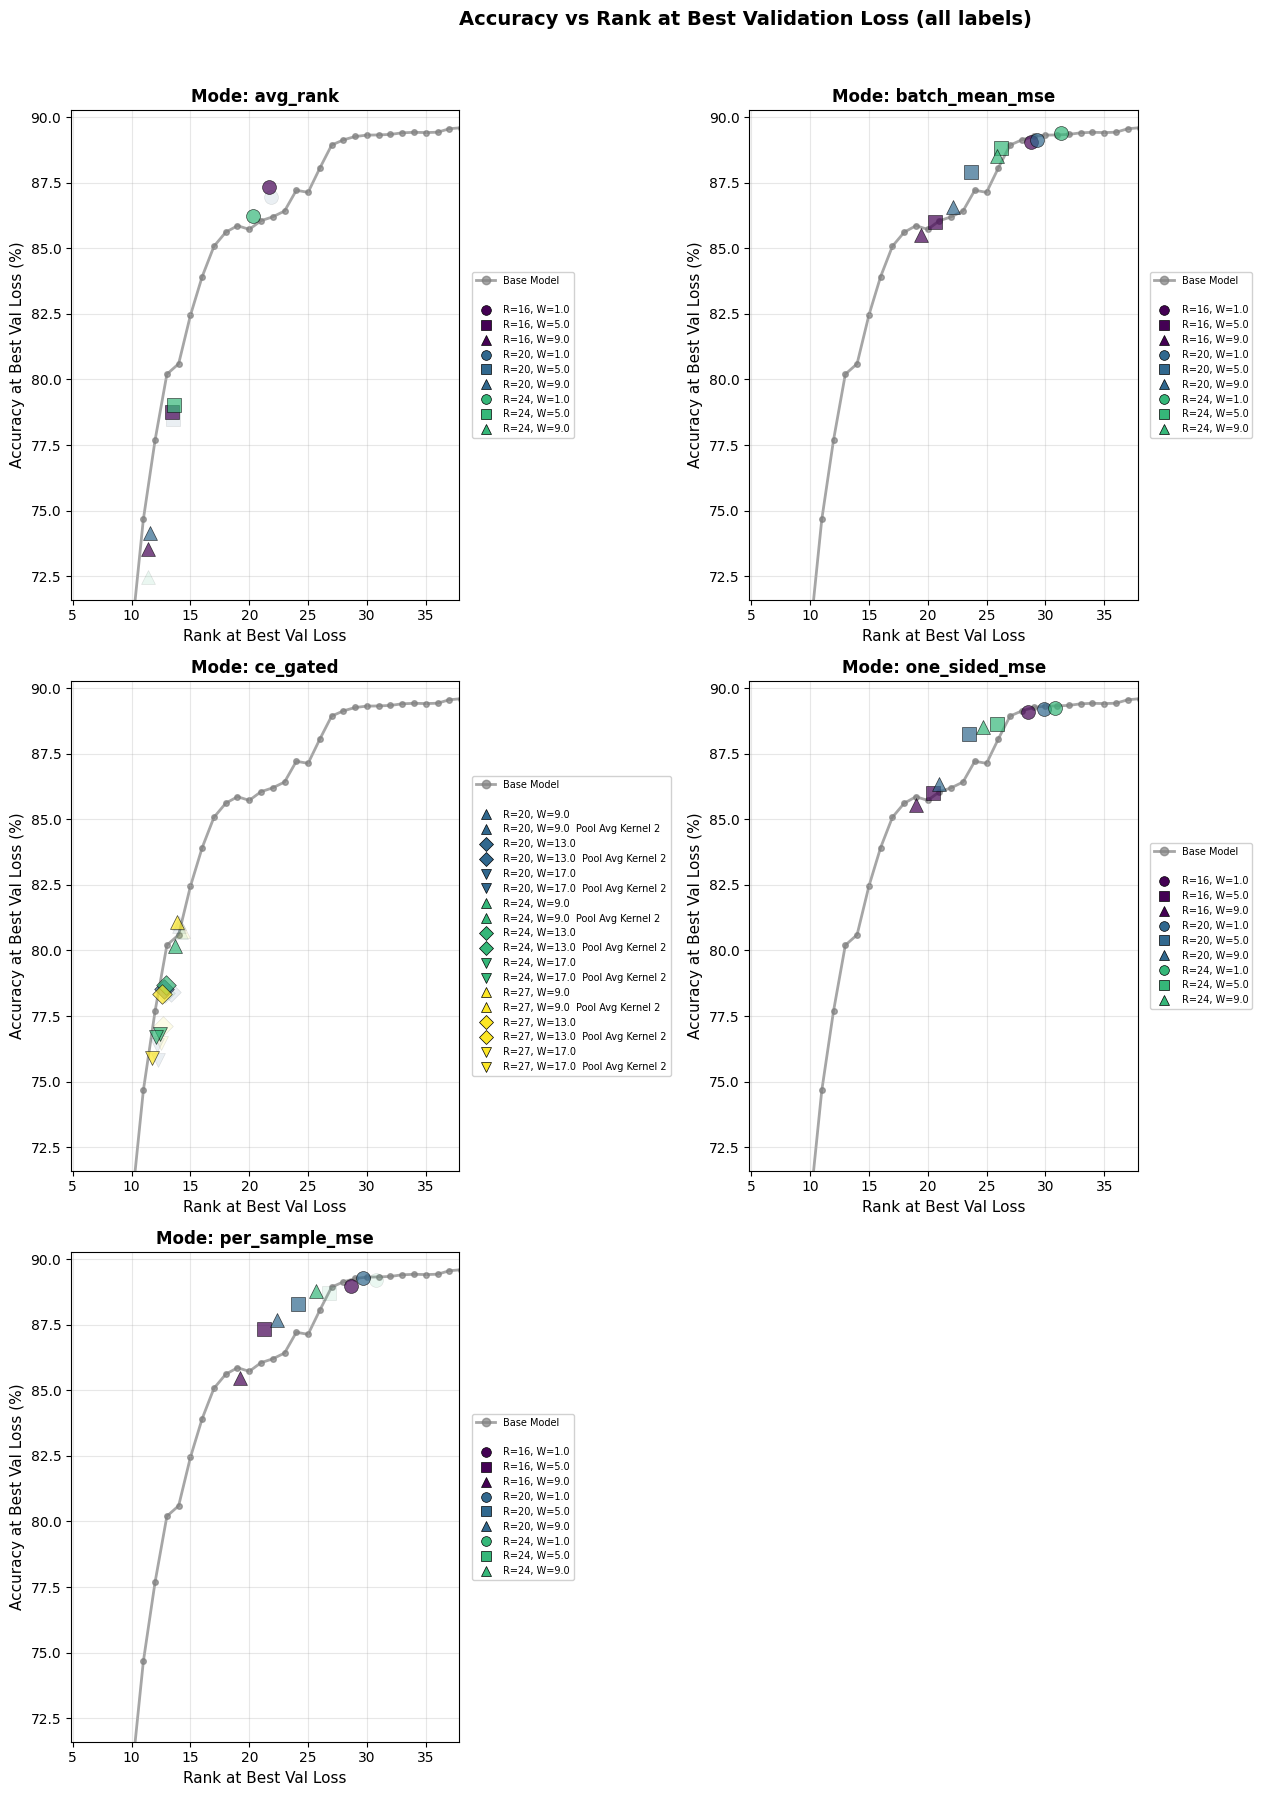

In [15]:
# Create the plot with base model overlay
fig = plot_rank_vs_acc_by_mode(sweep_results, df_base=df_base, include_silence=True)
plt.show()

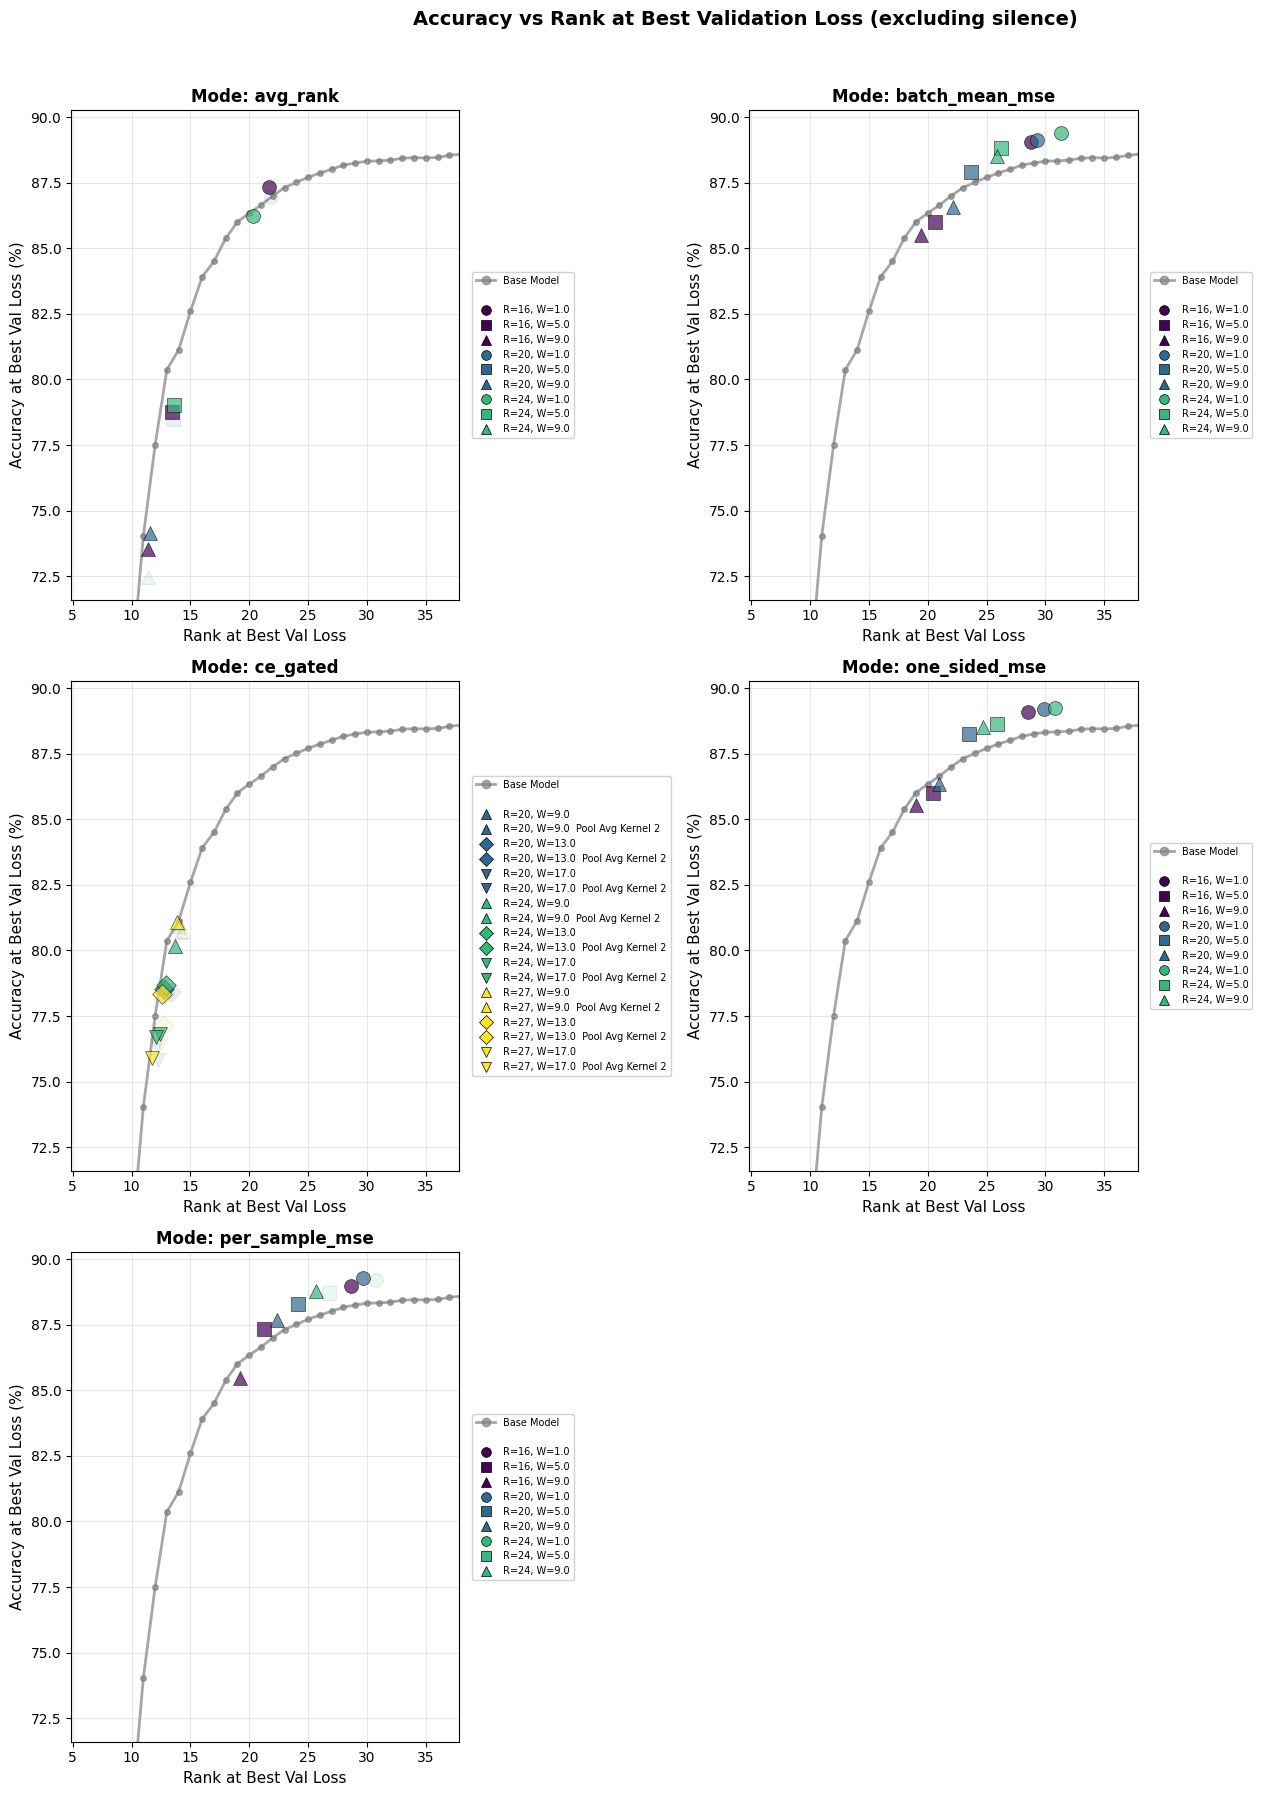

In [16]:
# Create the plot excluding silence labels
fig = plot_rank_vs_acc_by_mode(sweep_results, df_base=df_base, include_silence=False)
plt.show()